In [1]:
import agama
import cmasher as cmr
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde, lognorm
from sklearn.svm import SVC, LinearSVC

agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()

# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

KeyboardInterrupt: 

In [ ]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_cmap = plt.get_cmap("tab10")
sim_colors = [sim_cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

sim_dir = "/Users/z5114326/Documents/simulations/"

snap = 600

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
time = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])

In [ ]:
sim_dict = {}
for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    sim_dict[sim] = {}
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]

        amsk = src_dat["grpid"][()] == 0
        grpid = src_dat["grpid"][()]

        m_tfo = 10 ** src_dat["logm_tfor"][()]
        m_tfo_ev = 0.55 * (10 ** src_dat["logm_tfor"][()])

        m_tz0_log = src_dat["logm_tz0"][()]
        m_tz0 = np.array([10**x if x != -1 else 0 for x in m_tz0_log])

        tfor = src_dat["tfor"][()]
        tdis = src_dat["tdis"][()]
        tacc = src_dat["tacc"][()]

        age = time - tfor
        age_p = np.array([x - y if x != -1 else time - y for x, y in zip(tdis, tfor)])

        t_tz0 = src_dat["torb_600"][()]
        s_tz0 = np.array(src_dat["s_flag"][()], dtype=bool)

        ml = m_tfo_ev - m_tz0
        ml_rate = (m_tfo_ev - m_tz0) / age_p

        sim_dict[sim][it_id] = {}
        sim_dict[sim][it_id]["m_tfo"] = m_tfo
        sim_dict[sim][it_id]["m_tfo_ev"] = m_tfo_ev
        sim_dict[sim][it_id]["m_tz0"] = m_tz0
        sim_dict[sim][it_id]["tfor"] = tfor
        sim_dict[sim][it_id]["tdis"] = tdis
        sim_dict[sim][it_id]["age"] = age
        sim_dict[sim][it_id]["age_p"] = age_p
        sim_dict[sim][it_id]["t_tz0"] = t_tz0
        sim_dict[sim][it_id]["s_tz0"] = s_tz0
        sim_dict[sim][it_id]["ml"] = ml
        sim_dict[sim][it_id]["ml_rate"] = ml_rate
        sim_dict[sim][it_id]["acc"] = amsk
        sim_dict[sim][it_id]["grp"] = grpid

In [ ]:
fit_dict = {sim: {"in_situ": {}, "ex_situ": {}} for sim in sim_lst}

tfor_lim = False
tfor_min = 0
tfor_max = 6

for sim in fit_dict.keys():
    for it_id in sim_dict[sim].keys():
        smsk = sim_dict[sim][it_id]["s_tz0"]
        for acc in fit_dict[sim].keys():
            if acc == "in_situ":
                amsk = sim_dict[sim][it_id]["acc"]
            else:
                amsk = ~sim_dict[sim][it_id]["acc"]

            if tfor_lim:
                tmsk = (tfor_min <= sim_dict[sim][it_id]["tfor"]) & (sim_dict[sim][it_id]["tfor"] < tfor_max)
            else:
                tmsk = np.ones(len(smsk), dtype=bool)

            x_s = sim_dict[sim][it_id]["m_tfo"][smsk & amsk & tmsk]
            y_s = sim_dict[sim][it_id]["t_tz0"][smsk & amsk & tmsk]

            x_d = sim_dict[sim][it_id]["m_tfo"][~smsk & amsk & tmsk]
            y_d = sim_dict[sim][it_id]["t_tz0"][~smsk & amsk & tmsk]

            # Stack features in log10 space
            Xd = np.stack((np.log10(x_d), np.log10(y_d)), axis=1)
            Xs = np.stack((np.log10(x_s), np.log10(y_s)), axis=1)
            Xds = np.vstack((Xd, Xs))

            y = np.array([0] * len(Xd) + [1] * len(Xs))  # labels

            # Train linear SVM
            clf = SVC(kernel="linear")
            clf.fit(Xds, y)

            # Decision boundary in log10 space
            w = clf.coef_[0]
            b = clf.intercept_[0]

            m = -(w[0] / w[1])
            c = -(b / w[1])

            fit_dict[sim][acc][it_id] = {"m": m, "c": c}

m12b in_situ - $\log_{10} \mathrm{P}_{z=0} = (-1.42 \pm 0.09) \log_{10} \mathrm{M}_{form} + (10.25 \pm 0.52)$
m12c in_situ - $\log_{10} \mathrm{P}_{z=0} = (-2.85 \pm 0.73) \log_{10} \mathrm{M}_{form} + (17.85 \pm 4.09)$
m12f in_situ - $\log_{10} \mathrm{P}_{z=0} = (-1.28 \pm 0.08) \log_{10} \mathrm{M}_{form} + (9.24 \pm 0.42)$
m12i in_situ - $\log_{10} \mathrm{P}_{z=0} = (-1.50 \pm 0.11) \log_{10} \mathrm{M}_{form} + (10.38 \pm 0.61)$
m12m in_situ - $\log_{10} \mathrm{P}_{z=0} = (-2.17 \pm 0.20) \log_{10} \mathrm{M}_{form} + (14.14 \pm 1.11)$

m12b ex_situ - $\log_{10} \mathrm{P}_{z=0} = (-3.32 \pm 0.48) \log_{10} \mathrm{M}_{form} + (20.92 \pm 2.66)$
m12c ex_situ - $\log_{10} \mathrm{P}_{z=0} = (-3.22 \pm 0.51) \log_{10} \mathrm{M}_{form} + (20.53 \pm 3.38)$
m12f ex_situ - $\log_{10} \mathrm{P}_{z=0} = (-3.37 \pm 0.46) \log_{10} \mathrm{M}_{form} + (20.68 \pm 2.41)$
m12i ex_situ - $\log_{10} \mathrm{P}_{z=0} = (-3.51 \pm 0.54) \log_{10} \mathrm{M}_{form} + (21.35 \pm 2.88)$
m12m ex_si

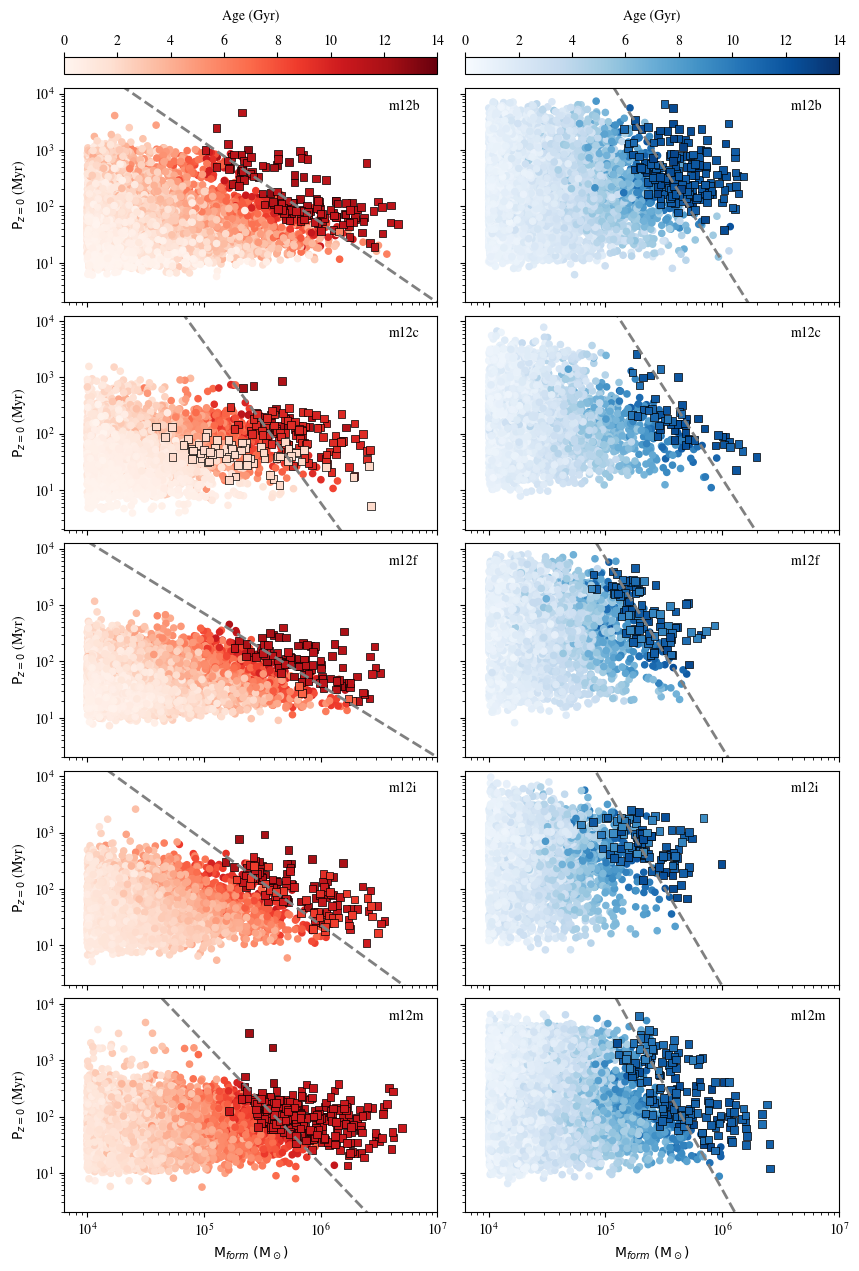

In [ ]:
fig = plt.figure(figsize=(30 / 3, 15))

gs = GridSpec(6, 2, height_ratios=[0.08, 1, 1, 1, 1, 1], hspace=0.075, wspace=0.075)

plt_text = False

vmin = 0
vmax = 14
cmaps = ["Reds", "Blues"]
cs = ["r", "b"]
accs = ["in_situ", "ex_situ"]

it_id_example = "it001"
scatters = [None, None]
first_axes = [None, None]

xfit = np.logspace(3, 7)
xfitlog = np.log10(xfit)

for col in range(2):
    acc = accs[col]
    cmap = cmaps[col]

    for row, sim in enumerate(sim_lst):
        # Create subplot, share x with first axis in column
        if row == 0:
            ax = fig.add_subplot(gs[row + 1, col])
            first_axes[col] = ax
        else:
            ax = fig.add_subplot(gs[row + 1, col], sharex=first_axes[col], sharey=first_axes[col])

        # ---- Compute fit statistics ----
        m_vals = [fit_dict[sim][acc][it_id]["m"] for it_id in fit_dict[sim][acc].keys()]
        c_vals = [fit_dict[sim][acc][it_id]["c"] for it_id in fit_dict[sim][acc].keys()]

        m = np.mean(m_vals)
        dm = np.std(m_vals)

        c = np.mean(c_vals)
        dc = np.std(c_vals)

        # ---- Masking ----
        smsk = sim_dict[sim][it_id_example]["s_tz0"]
        if acc == "in_situ":
            amsk = sim_dict[sim][it_id_example]["acc"]
        else:
            amsk = ~sim_dict[sim][it_id_example]["acc"]

        if tfor_lim:
            tmsk = (tfor_min <= sim_dict[sim][it_id_example]["tfor"]) & (
                sim_dict[sim][it_id_example]["tfor"] < tfor_max
            )
        else:
            tmsk = np.ones(len(smsk), dtype=bool)

        x_s = sim_dict[sim][it_id_example]["m_tfo"][smsk & amsk & tmsk]
        y_s = sim_dict[sim][it_id_example]["t_tz0"][smsk & amsk & tmsk]
        c_s = sim_dict[sim][it_id_example]["age_p"][smsk & amsk & tmsk]

        x_d = sim_dict[sim][it_id_example]["m_tfo"][~smsk & amsk & tmsk]
        y_d = sim_dict[sim][it_id_example]["t_tz0"][~smsk & amsk & tmsk]
        c_d = sim_dict[sim][it_id_example]["age_p"][~smsk & amsk & tmsk]

        ss = ax.scatter(x_s, y_s, c=c_s, s=30, cmap=cmap, vmin=vmin, vmax=vmax, ec="k", lw=0.5, marker="s")
        sd = ax.scatter(x_d, y_d, c=c_d, s=20, cmap=cmap, vmin=vmin, vmax=vmax, zorder=0)

        yfitlog = xfitlog * m + c
        yfit = 10**yfitlog
        ax.plot(xfit, yfit, c="grey", ls="--", lw=2)

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_xlim(10**3.8, 10**7)
        ax.set_ylim(10**0.3, 10**4.1)

        # Hide xlabel and x-ticks on all but the bottom row
        if row != len(sim_lst) - 1:
            ax.tick_params(labelbottom=False)
        else:
            # ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$", fontsize=12)
            ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")

        if col == 1:
            ax.tick_params(labelleft=False)
        else:
            # ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)", fontsize=12)
            ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

        # Store scatter for colorbar (top row)
        if row == 0:
            scatters[col] = sd

        print(
            sim,
            acc,
            "-",
            rf"$\log_{{10}} \mathrm{{P}}_{{z=0}} = ({m:.2f} \pm {dm:.2f}) \log_{{10}} \mathrm{{M}}_{{form}} + ({c:.2f} \pm {dc:.2f})$",
        )
        if plt_text:
            boundary = rf"$\log_{{10}} \mathrm{{P}}_{{z=0}} = ({m:.2f} \pm {dm:.2f}) \log_{{10}} \mathrm{{M}}_{{form}} + ({c:.2f} \pm {dc:.2f})$"
            ax.text(
                0.35,
                0.92,
                boundary,
                transform=ax.transAxes,
                # fontsize=10,
                color="k",
                ha="left",
                bbox=dict(
                    facecolor="white",
                    edgecolor="white",
                ),
            )

        ax.text(
            0.87,
            0.90,
            sim,
            transform=ax.transAxes,
            # fontsize=12,
            color="k",
            ha="left",
            bbox=dict(
                facecolor="white",
                edgecolor="white",
            ),
        )
    print("")

# ---- Colorbars on top row ----
for col in range(2):
    cax = fig.add_subplot(gs[0, col])
    cb = fig.colorbar(scatters[col], cax=cax, orientation="horizontal")
    cb.ax.set_xticks([0, 2, 4, 6, 8, 10, 12, 14])
    cax.xaxis.set_ticks_position("top")
    cax.xaxis.set_label_position("top")
    cb.set_label("Age (Gyr)", labelpad=10)
    # Hide tick labels for colorbar row if desired:
    # cax.tick_params(labelbottom=False, labeltop=True)

plt.show()

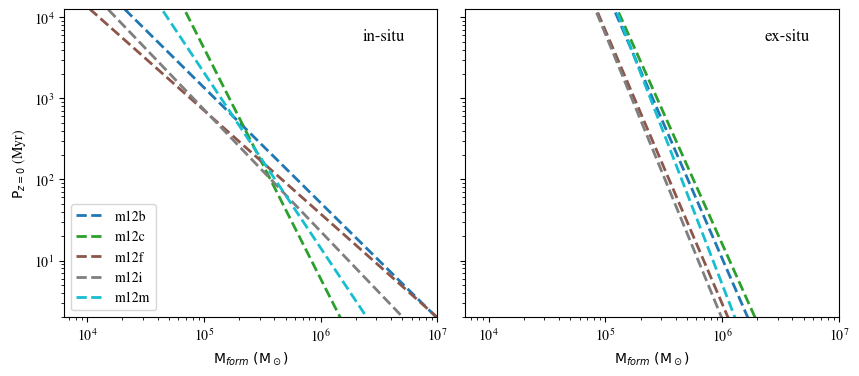

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(30 / 3, 4), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.075)

acc_labels = ["in-situ", "ex-situ"]

for i, acc in enumerate(accs):
    for j, sim in enumerate(sim_lst):
        m_vals = [fit_dict[sim][acc][it_id]["m"] for it_id in fit_dict[sim][acc].keys()]
        c_vals = [fit_dict[sim][acc][it_id]["c"] for it_id in fit_dict[sim][acc].keys()]

        m = np.mean(m_vals)
        dm = np.std(m_vals)

        c = np.mean(c_vals)
        dc = np.std(c_vals)

        yfitlog = xfitlog * m + c
        yfit = 10**yfitlog
        axs[i].plot(xfit, yfit, c=sim_colors[j], ls="--", lw=2, label=sim)

    axs[i].text(
        0.80,
        0.90,
        acc_labels[i],
        transform=axs[i].transAxes,
        fontsize=12,
        color="k",
        ha="left",
        # bbox=dict(
        #     facecolor="white",
        #     edgecolor="white",
        # ),
    )

    axs[i].set_xscale("log")
    axs[i].set_yscale("log")

    axs[i].set_xlim(10**3.8, 10**7)
    axs[i].set_ylim(10**0.3, 10**4.1)

    axs[i].set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")

    if i == 1:
        axs[i].tick_params(labelleft=False)
    else:
        axs[i].set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")
        axs[i].legend(loc="lower left")

In [ ]:
def plot_lim(x, y, msk):
    x_is = x[msk]
    y_is = y[msk]

    x_id = x[~msk]
    y_id = y[~msk]

    # Stack features in log10 space
    Xd = np.stack((np.log10(x_id), np.log10(y_id)), axis=1)
    Xs = np.stack((np.log10(x_is), np.log10(y_is)), axis=1)
    Xds = np.vstack((Xd, Xs))

    y = np.array([0] * len(Xd) + [1] * len(Xs))  # labels

    # Train linear SVM
    clf = SVC(kernel="linear")
    clf.fit(Xds, y)

    # Decision boundary in log10 space
    w = clf.coef_[0]
    b = clf.intercept_[0]

    m = -(w[0] / w[1])
    c = -(b / w[1])

    return m, c


def life_cut(ax, x, y, c, c_level, xfitlog, plot=True, ytlog=0.7, label=None):
    msk = c <= c_level
    m, b = plot_lim(x, y, msk)

    yfitlog = m * xfitlog + b
    yfit = 10**yfitlog

    if not plot:
        return yfit

    if label is None:
        label = f"{c_level} Gyr"
    ax.plot(xfit, yfit, c="grey", ls="--")

    # --- label position (on the line) ---
    xtlog = (ytlog - b) / m
    # x0, y0 = 10**xtlog, 10**ytlog

    # compute screen-space angle
    dx = 0.1
    x1log, x2log = xtlog, xtlog + dx
    y1log = m * x1log + b
    y2log = m * x2log + b

    p1 = ax.transData.transform((10**x1log, 10**y1log))
    p2 = ax.transData.transform((10**x2log, 10**y2log))

    angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))

    # --- offset perpendicular to the line (in pixels) ---
    offset_pixels = 17  # increase for more separation

    normal = np.array([-(p2[1] - p1[1]), p2[0] - p1[0]])
    normal = normal / np.linalg.norm(normal)

    p_text = p1 + offset_pixels * normal

    # convert back to data coords
    x_text, y_text = ax.transData.inverted().transform(p_text)

    # ax.text(
    #     x_text,
    #     y_text,
    #     label,
    #     rotation=angle,
    #     rotation_mode="anchor",
    #     ha="left",
    #     va="top",
    #     color="grey",
    #     bbox=dict(facecolor="none", alpha=0.6, edgecolor="none"),
    #     zorder=5,
    #     # transform=ax.transAxes,
    # )


def lower_envelope(x, m, x_b, y_b):
    return np.where(x < x_b, m * (x - x_b) + y_b, y_b)


def kde_threshold(Z, fraction):
    """Return KDE level that encloses fraction of total probability."""
    sorted_Z = np.sort(Z.ravel())[::-1]  # descending
    cumsum = np.cumsum(sorted_Z)
    cumsum /= cumsum[-1]  # normalize
    # Find the smallest Z value where cumulative sum >= fraction
    level = sorted_Z[np.searchsorted(cumsum, fraction)]
    return level


def plot_bounding(x, y, fraction=0.98):

    xlog = np.log10(x)
    ylog = np.log10(y)

    # --- KDE ---
    xy = np.vstack([xlog, ylog])
    kde = gaussian_kde(xy)

    X, Y = np.meshgrid(np.linspace(xlog.min(), xlog.max(), 200), np.linspace(ylog.min(), ylog.max(), 200))
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    # --- Generate contour using a temporary figure ---
    fig, ax = plt.subplots()
    cont = ax.contour(X, Y, Z, levels=[kde_threshold(Z, fraction)])
    plt.close(fig)  # close figure immediately, no plotting

    # Pick the largest contour
    contour_path = max(cont.collections[0].get_paths(), key=lambda p: p.vertices.shape[0])
    vertices = contour_path.vertices
    x_contour, y_contour = vertices[:, 0], vertices[:, 1]

    # --- Lower envelope ---
    bins = np.linspace(x_contour.min(), x_contour.max(), 100)
    x_bin_centers = 0.5 * (bins[:-1] + bins[1:])
    x_lower, y_lower = [], []

    for i in range(len(bins) - 1):
        mask = (x_contour >= bins[i]) & (x_contour < bins[i + 1])
        if np.any(mask):
            x_lower.append(x_bin_centers[i])
            y_lower.append(np.min(y_contour[mask]))

    x_lower = np.array(x_lower)
    y_lower = np.array(y_lower)

    # --- Fit lower envelope ---
    p0 = [-1, np.median(x_lower), np.median(y_lower)]
    params, cov = curve_fit(lower_envelope, x_lower, y_lower, p0=p0)

    xfit = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
    yfit = 10 ** lower_envelope(np.log10(xfit), *params)

    return {"xfit": xfit, "yfit": yfit, "params": params, "cov": cov}


def sep_func(Xlog, labels):
    clf = LinearSVC(dual=False)
    # clf = SVC(kernel="linear")
    clf.fit(Xlog, labels)

    w = clf.coef_[0]
    b = clf.intercept_[0]

    m = -(w[0] / w[1])
    c = -(b / w[1])

    return m, c

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_40483/3302559517.py:116: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = max(cont.collections[0].get_paths(), key=lambda p: p.vertices.shape[0])


m12b in_situ [-0.41451106  4.88289148  1.23301731]



/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_40483/3302559517.py:116: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = max(cont.collections[0].get_paths(), key=lambda p: p.vertices.shape[0])


m12c in_situ [-0.39545202  4.52392753  1.10326533]



/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_40483/3302559517.py:116: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = max(cont.collections[0].get_paths(), key=lambda p: p.vertices.shape[0])


...

m12f ex_situ [-0.6742557   3.90087128  1.87398757]



/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_40483/3302559517.py:116: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = max(cont.collections[0].get_paths(), key=lambda p: p.vertices.shape[0])


m12i ex_situ [-0.61993497  4.32444375  1.69287626]



/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_40483/3302559517.py:116: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = max(cont.collections[0].get_paths(), key=lambda p: p.vertices.shape[0])


m12m ex_situ [-1.14696768  4.15172897  1.2774617 ]



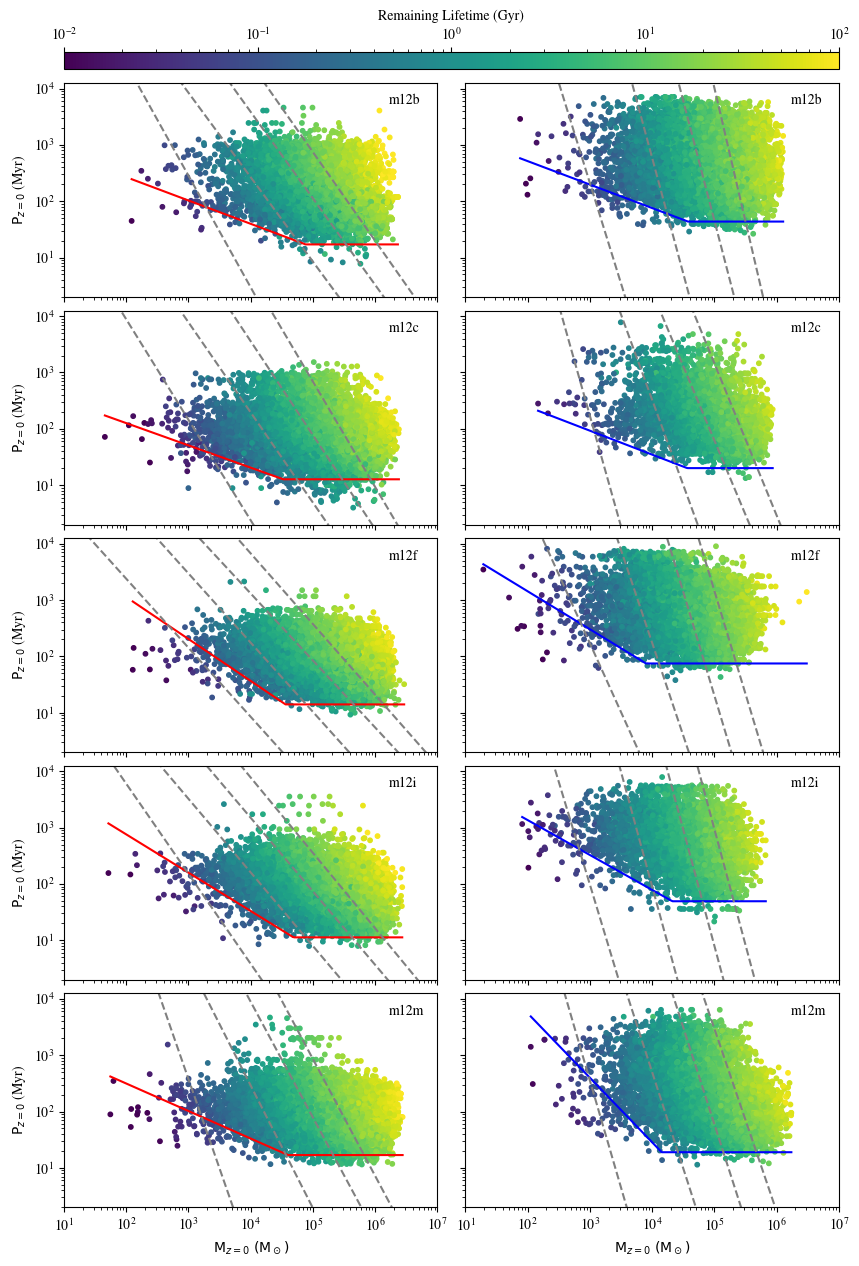

In [ ]:
fig = plt.figure(figsize=(30 / 3, 15))

gs = GridSpec(6, 2, height_ratios=[0.08, 1, 1, 1, 1, 1], hspace=0.075, wspace=0.075)

scatters = [None, None]
first_axes = [None, None]

xfit = np.logspace(1, 7)
xfitlog = np.log10(xfit)

age_lst = [0.1, 1, 5, time]

boundary = True
# birth_lim = True
# turn_off_mass = True

lvmin = 10**-2
lvmax = 10**2
norm = LogNorm(vmin=lvmin, vmax=lvmax)
shared_scatter = None

for col in range(2):
    acc = accs[col]
    cmap = cmaps[col]
    c = cs[col]

    for row, sim in enumerate(sim_lst):
        # Create subplot, share x with first axis in column
        if row == 0:
            ax = fig.add_subplot(gs[row + 1, col])
            first_axes[col] = ax
        else:
            ax = fig.add_subplot(gs[row + 1, col], sharex=first_axes[col], sharey=first_axes[col])

        x = np.array([])
        y = np.array([])
        c = np.array([])

        for it_id in sim_dict[sim].keys():
            # --- Combine all data ---
            smsk_i = sim_dict[sim][it_id]["s_tz0"][()]
            if acc == "in_situ":
                amsk_i = sim_dict[sim][it_id]["acc"][()]
            else:
                amsk_i = ~sim_dict[sim][it_id]["acc"][()]
            msk_i = smsk_i & amsk_i

            x_i = sim_dict[sim][it_id]["m_tz0"][msk_i]
            y_i = sim_dict[sim][it_id]["t_tz0"][msk_i]
            ml_rate_i = sim_dict[sim][it_id]["ml_rate"][msk_i]

            c_i = x_i / ml_rate_i

            x = np.concatenate((x, x_i))
            y = np.concatenate((y, y_i))
            c = np.concatenate((c, c_i))

        if boundary:
            plot_dict = plot_bounding(x, y, fraction=0.98)
            ax.plot(plot_dict["xfit"], plot_dict["yfit"], c=cs[col])
            print(sim, acc, plot_dict["params"])
            print()

        sc = ax.scatter(x, y, c=c, s=10, norm=norm)
        if shared_scatter is None:
            shared_scatter = sc

        for age_cut in age_lst:
            label = None
            if age_cut == time:
                label = "Hubble Time"
            life_cut(ax, x, y, c, age_cut, xfitlog, label=label)

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_xlim(10**1, 10**7)
        ax.set_ylim(10**0.3, 10**4.1)

        # Hide xlabel and x-ticks on all but the bottom row
        if row != len(sim_lst) - 1:
            ax.tick_params(labelbottom=False)
        else:
            # ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$", fontsize=12)
            ax.set_xlabel(r"$\mathrm{M}_{z=0}\ (\mathrm{M}_\odot)$")

        if col == 1:
            ax.tick_params(labelleft=False)
        else:
            # ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)", fontsize=12)
            ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

        ax.text(
            0.87,
            0.90,
            sim,
            transform=ax.transAxes,
            # fontsize=12,
            color="k",
            ha="left",
            bbox=dict(
                facecolor="white",
                edgecolor="white",
            ),
        )

cax = fig.add_subplot(gs[0, :])  # top row, span both columns

cbar = fig.colorbar(shared_scatter, cax=cax, orientation="horizontal")
cbar.set_label(r"Remaining Lifetime (Gyr)")

# Put ticks on top (optional, looks nicer for top colorbar)
cax.xaxis.set_ticks_position("top")
cax.xaxis.set_label_position("top")

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_40483/3302559517.py:116: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = max(cont.collections[0].get_paths(), key=lambda p: p.vertices.shape[0])


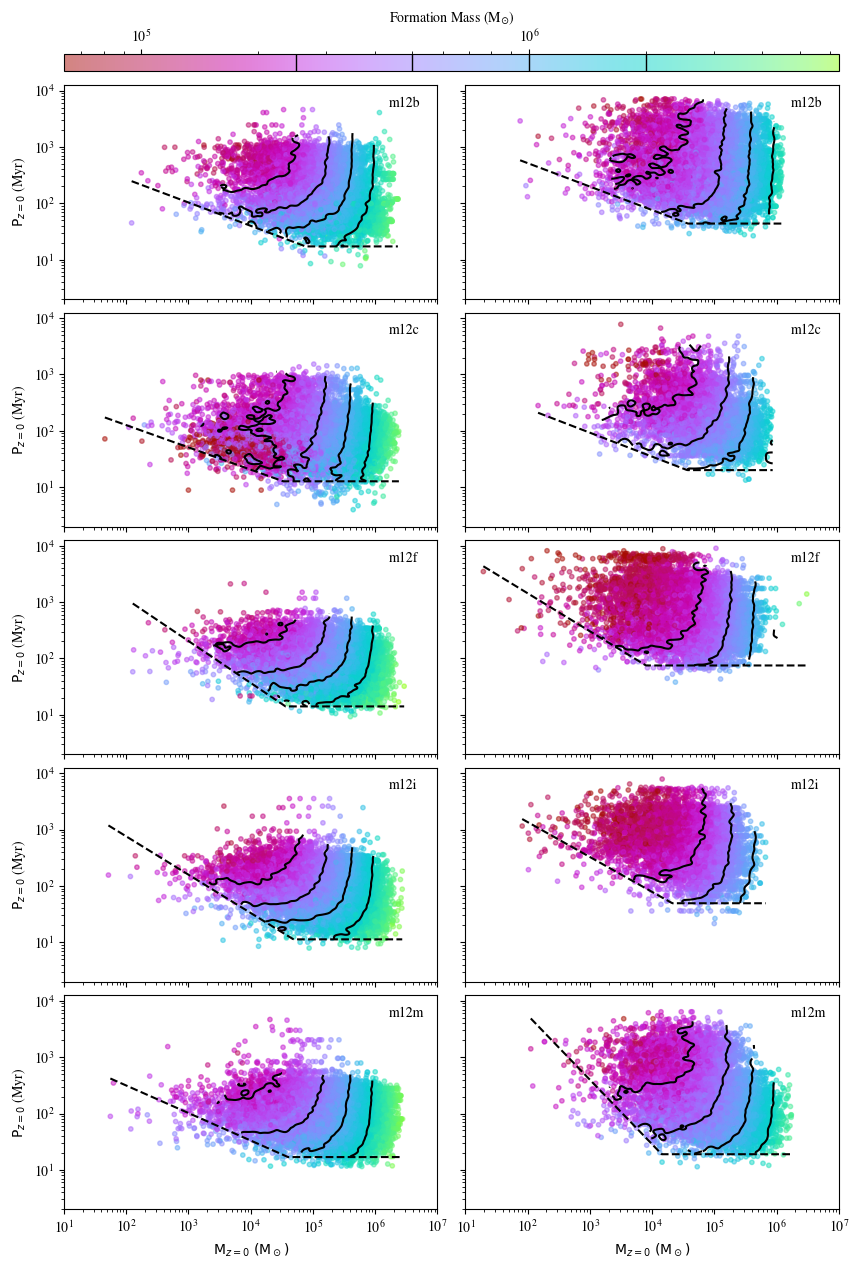

In [ ]:
fig = plt.figure(figsize=(30 / 3, 15))
gs = GridSpec(6, 2, height_ratios=[0.08, 1, 1, 1, 1, 1], hspace=0.075, wspace=0.075)

cmap = cmr.neon
norm = LogNorm(vmin=10**4.8, vmax=10**6.8)
shared_scatter = None

mass_levels = np.array([2.5, 5, 10, 20]) * 10**5

for col in range(2):
    acc = accs[col]
    c = cs[col]

    for row, sim in enumerate(sim_lst):
        # Create subplot, share x with first axis in column
        if row == 0:
            ax = fig.add_subplot(gs[row + 1, col])
            first_axes[col] = ax
        else:
            ax = fig.add_subplot(gs[row + 1, col], sharex=first_axes[col], sharey=first_axes[col])

        x = np.array([])
        y = np.array([])
        c = np.array([])

        for it_id in sim_dict[sim].keys():
            # --- Combine all data ---
            smsk_i = sim_dict[sim][it_id]["s_tz0"][()]
            if acc == "in_situ":
                amsk_i = sim_dict[sim][it_id]["acc"][()]
            else:
                amsk_i = ~sim_dict[sim][it_id]["acc"][()]
            msk_i = smsk_i & amsk_i

            x_i = sim_dict[sim][it_id]["m_tz0"][msk_i]
            y_i = sim_dict[sim][it_id]["t_tz0"][msk_i]
            c_i = sim_dict[sim][it_id]["m_tfo"][msk_i]

            x = np.concatenate((x, x_i))
            y = np.concatenate((y, y_i))
            c = np.concatenate((c, c_i))

        xlog = np.log10(x)
        ylog = np.log10(y)
        clog = np.log10(c)

        xlog_ylog = np.vstack([xlog, ylog])
        kde = gaussian_kde(xlog_ylog)
        z = kde(xlog_ylog)

        threshold = np.percentile(z, 2)  # 5th percentile corresponds to outside 95%

        xlog_msk = xlog.copy()
        ylog_msk = ylog.copy()
        clog_msk = clog.copy()

        xlog_msk[z < threshold] = np.nan
        ylog_msk[z < threshold] = np.nan
        clog_msk[z < threshold] = np.nan

        if boundary:
            plot_dict = plot_bounding(x, y, fraction=0.98)
            ax.plot(plot_dict["xfit"], plot_dict["yfit"], c="k", ls="--")

        xbound = plot_dict["xfit"]
        ybound = plot_dict["yfit"]

        xbound_log = np.log10(xbound)
        ybound_log = np.log10(ybound)

        # Create grid
        xi = np.linspace(np.min(xlog), np.max(xlog), 200)
        yi = np.linspace(np.min(ylog), np.max(ylog), 200)
        Xi, Yi = np.meshgrid(xi, yi)

        Zi_linear = griddata((xlog, ylog), clog, (Xi, Yi), method="linear")
        Zi_nearest = griddata((xlog, ylog), clog, (Xi, Yi), method="nearest")
        Zi = np.where(np.isnan(Zi_linear), Zi_nearest, Zi_linear)

        Zi_smooth = gaussian_filter(Zi, sigma=2)  # Increase sigma for smoother lines

        # Boundary mask
        y_boundary = np.interp(Xi[0, :], xbound_log, ybound_log)
        Y_boundary = np.tile(y_boundary, (Yi.shape[0], 1))
        boundary_mask = Yi >= Y_boundary  # True where we keep values

        # KDE threshold mask
        # Interpolate z (density) onto the grid
        Zi_kde = griddata((xlog, ylog), z, (Xi, Yi), method="nearest")  # nearest avoids NaNs
        kde_mask = Zi_kde >= threshold  # True where density is above threshold

        # Combine both masks
        combined_mask = boundary_mask & kde_mask

        # Apply mask to smoothed Zi
        Zi_masked = np.where(combined_mask, Zi_smooth, np.nan)

        sc = ax.scatter(x, y, c=c, s=10, alpha=0.5, norm=norm, cmap=cmap)
        if shared_scatter is None:
            shared_scatter = sc

        ax.contour(10**Xi, 10**Yi, 10**Zi_masked, levels=mass_levels, colors="k", linewidths=1.5)

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_xlim(10**1, 10**7)
        ax.set_ylim(10**0.3, 10**4.1)

        # Hide xlabel and x-ticks on all but the bottom row
        if row != len(sim_lst) - 1:
            ax.tick_params(labelbottom=False)
        else:
            # ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$", fontsize=12)
            ax.set_xlabel(r"$\mathrm{M}_{z=0}\ (\mathrm{M}_\odot)$")

        if col == 1:
            ax.tick_params(labelleft=False)
        else:
            # ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)", fontsize=12)
            ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

        ax.text(
            0.87,
            0.90,
            sim,
            transform=ax.transAxes,
            # fontsize=12,
            color="k",
            ha="left",
            bbox=dict(
                facecolor="white",
                edgecolor="white",
            ),
        )

cax = fig.add_subplot(gs[0, :])  # top row, span both columns

cbar = fig.colorbar(shared_scatter, cax=cax, orientation="horizontal")
cbar.set_label(r"Formation Mass (M$_{\odot}$)")

# Put ticks on top (optional, looks nicer for top colorbar)
cax.xaxis.set_ticks_position("top")
cax.xaxis.set_label_position("top")

for level in mass_levels:
    cbar.ax.axvline(level, color="k", lw=1.0, ls="-")

In [ ]:
tdis_lst = np.array([4, 6, 8])

sep_dict = {sim: {acc: {tdis: {"m": [], "b": []} for tdis in tdis_lst} for acc in accs} for sim in sim_lst}

for col in range(2):
    acc_mode = accs[col]

    for sim in sim_lst:
        sim_data = sim_dict[sim]  # local reference (faster)

        for it_id, data in sim_data.items():
            # --- Pull arrays once ---
            acc_arr = sim_dict[sim][it_id]["acc"]
            if acc_mode == "in_situ":
                acc_msk = acc_arr
            else:
                acc_msk = ~acc_arr
            msk = acc_msk
            # testing
            # smsk = sim_dict[sim][it_id]["s_tz0"]
            # msk = acc_msk & ~smsk

            age_arr = sim_dict[sim][it_id]["age_p"][msk]
            x = sim_dict[sim][it_id]["m_tfo"][msk]
            y = sim_dict[sim][it_id]["t_tz0"][msk]

            Xlog = np.stack((np.log10(x), np.log10(y)), axis=1)

            age_positive = age_arr > 0

            # --- Loop over disruption times ---
            for tdis in tdis_lst:
                age_msk = age_positive & (age_arr <= tdis)
                labels = (age_msk).astype(int)

                # Skip pathological cases (all one class)
                if labels.sum() == 0 or labels.sum() == len(labels):
                    continue

                m, b = sep_func(Xlog, labels)

                sep_dict[sim][acc_mode][tdis]["m"].append(m)
                sep_dict[sim][acc_mode][tdis]["b"].append(b)

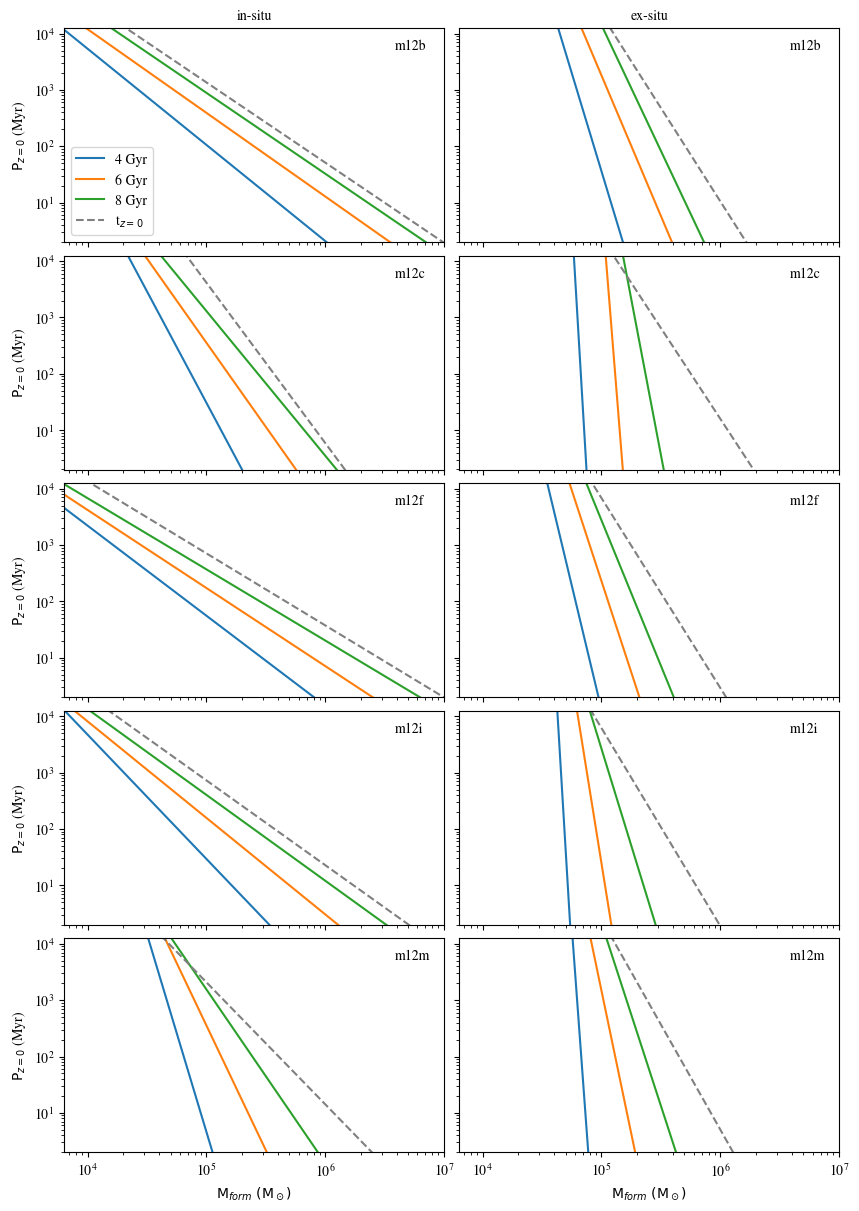

In [ ]:
fig = plt.figure(figsize=(30 / 3, 15))
gs = GridSpec(6, 2, height_ratios=[0.08, 1, 1, 1, 1, 1], hspace=0.075, wspace=0.04)

xfit = np.logspace(1, 7)
xfitlog = np.log10(xfit)

for col in range(2):
    acc = accs[col]
    cmap = cmaps[col]

    for row, sim in enumerate(sim_lst):
        # Create subplot, share x with first axis in column
        if row == 0:
            ax = fig.add_subplot(gs[row + 1, col])
            first_axes[col] = ax
            if acc == "in_situ":
                ax.set_title("in-situ")
            else:
                ax.set_title("ex-situ")
        else:
            ax = fig.add_subplot(gs[row + 1, col], sharex=first_axes[col], sharey=first_axes[col])

        for tdis in tdis_lst:
            m = np.mean(sep_dict[sim][acc][tdis]["m"])
            dm = np.std(sep_dict[sim][acc][tdis]["m"])

            b = np.mean(sep_dict[sim][acc][tdis]["b"])
            db = np.std(sep_dict[sim][acc][tdis]["b"])

            yfitlog = m * xfitlog + b
            yfit = 10**yfitlog

            ax.plot(xfit, yfit, label=str(tdis) + " Gyr")

        m_vals = [fit_dict[sim][acc][it_id]["m"] for it_id in fit_dict[sim][acc].keys()]
        b_vals = [fit_dict[sim][acc][it_id]["c"] for it_id in fit_dict[sim][acc].keys()]

        m = np.mean(m_vals)
        b = np.mean(b_vals)

        yfitlog = m * xfitlog + b
        yfit = 10**yfitlog

        ax.plot(xfit, yfit, label=r"t$_{z=0}$", c="grey", ls="--")

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_xlim(10**3.8, 10**7)
        ax.set_ylim(10**0.3, 10**4.1)

        # Hide xlabel and x-ticks on all but the bottom row
        if row != len(sim_lst) - 1:
            ax.tick_params(labelbottom=False)
        else:
            # ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$", fontsize=12)
            ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")

        if col == 1:
            ax.tick_params(labelleft=False)
        else:
            # ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)", fontsize=12)
            ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

        if (row == 0) & (col == 0):
            ax.legend(loc="lower left")

        ax.text(
            0.87,
            0.90,
            sim,
            transform=ax.transAxes,
            # fontsize=12,
            color="k",
            ha="left",
            bbox=dict(
                facecolor="white",
                edgecolor="white",
            ),
        )

Text(0, 0.5, '$\\mathrm{P}_{z=0}$ (Myr)')

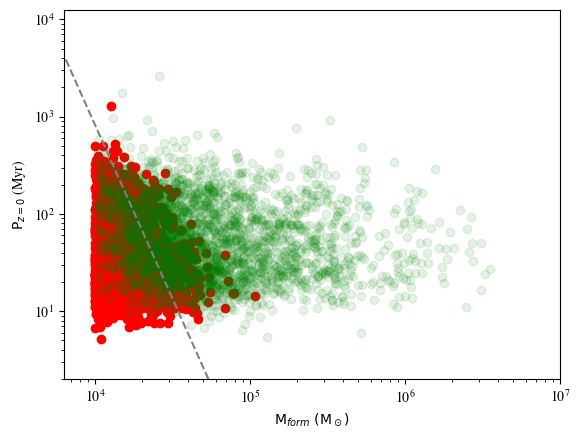

In [ ]:
sim = "m12i"
acc_mode = "in_situ"
tdis = 2
it_id = "it001"

acc_arr = sim_dict[sim][it_id]["acc"]
if acc_mode == "in_situ":
    acc_msk = acc_arr
else:
    acc_msk = ~acc_arr
msk = acc_msk
# testing
# smsk = sim_dict[sim][it_id]["s_tz0"]
# msk = acc_msk & ~smsk

age_arr = sim_dict[sim][it_id]["age_p"][msk]
x = sim_dict[sim][it_id]["m_tfo"][msk]
y = sim_dict[sim][it_id]["t_tz0"][msk]

Xlog = np.stack((np.log10(x), np.log10(y)), axis=1)

age_positive = age_arr > 0
age_msk = age_positive & (age_arr <= tdis)
labels = (age_msk).astype(int)
msk = (labels).astype(bool)

m, b = sep_func(Xlog, labels)

plt.scatter(x[msk], y[msk], c="r")
plt.scatter(x[~msk], y[~msk], c="g", alpha=0.1)

plt.xscale("log")
plt.yscale("log")

yfitlog = m * xfitlog + b
yfit = 10**yfitlog

plt.plot(xfit, yfit, label=str(tdis) + " Gyr", c="grey", ls="--")

plt.xlim(10**3.8, 10**7)
plt.ylim(10**0.3, 10**4.1)

plt.xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")
plt.ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

# Settling Time

In [ ]:
set_dict = {sim: {"in-situ": [], "ex-situ": []} for sim in sim_lst}

for sim in sim_lst:
    for acc in set_dict[sim].keys():
        for it_id in sim_dict[sim].keys():
            smsk_i = sim_dict[sim][it_id]["s_tz0"][()]
            if acc == "in-situ":
                amsk_i = sim_dict[sim][it_id]["acc"][()]
            else:
                amsk_i = ~sim_dict[sim][it_id]["acc"][()]
            msk_i = ~smsk_i & amsk_i

            x_i = sim_dict[sim][it_id]["age_p"]
            x_dat_i = x_i[msk_i]

            # Fit lognormal
            shape, loc, scale = lognorm.fit(x_dat_i, floc=0)  # force loc=0

            sigma = shape
            mu = np.log(scale)

            x_plus_1sigma = np.exp(mu + sigma)
            set_dict[sim][acc].append(x_plus_1sigma)

for sim in sim_lst:
    for acc in set_dict[sim].keys():
        men = np.round(np.mean(set_dict[sim][acc]), 2)
        std = np.round(np.std(set_dict[sim][acc]), 2)
        print(sim, acc, men, "+/-", std)
    print("")

m12b in-situ 3.28 +/- 0.07
m12b ex-situ 3.35 +/- 0.05

m12c in-situ 3.57 +/- 0.04
m12c ex-situ 3.49 +/- 0.05

m12f in-situ 3.26 +/- 0.1
m12f ex-situ 3.98 +/- 0.05

m12i in-situ 3.66 +/- 0.16
m12i ex-situ 4.16 +/- 0.06

m12m in-situ 3.72 +/- 0.03
m12m ex-situ 3.59 +/- 0.05



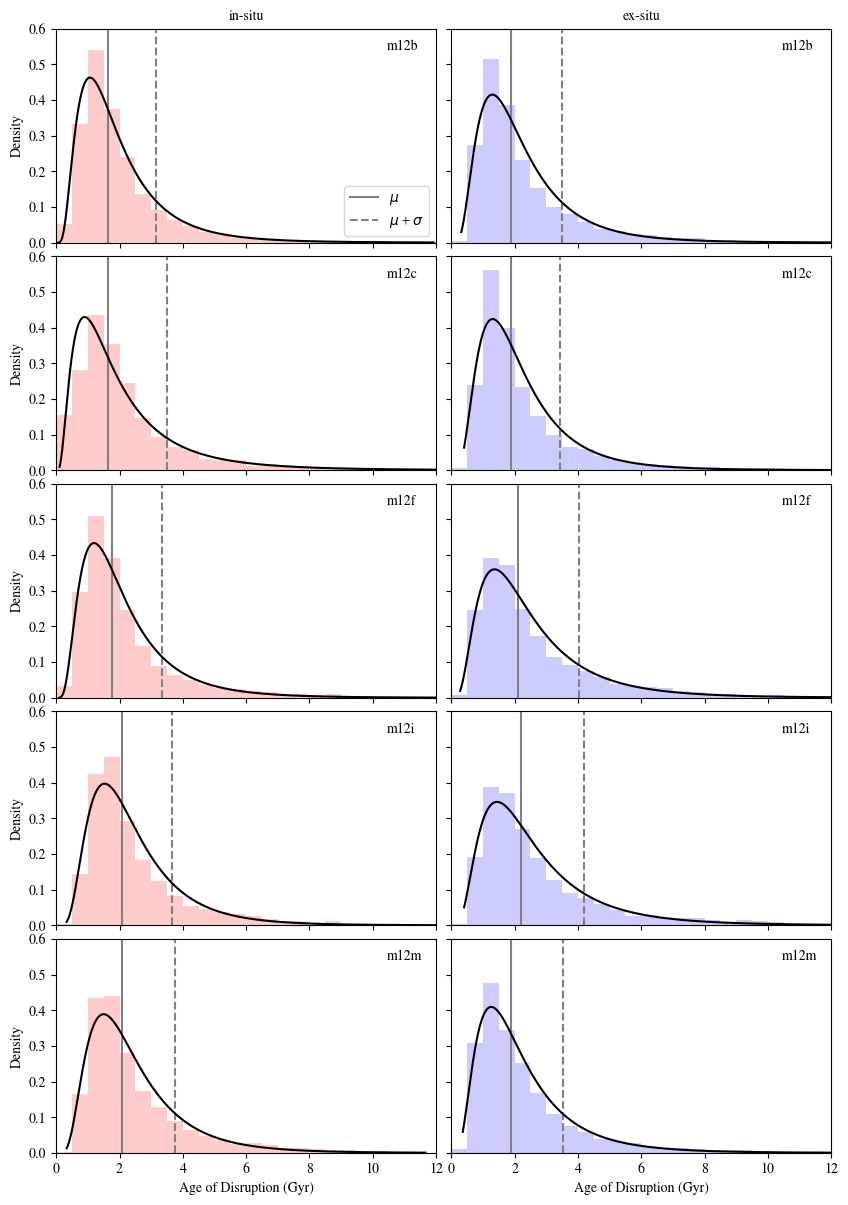

In [ ]:
it_id = "it001"

fig = plt.figure(figsize=(30 / 3, 15))
gs = GridSpec(6, 2, height_ratios=[0.08, 1, 1, 1, 1, 1], hspace=0.075, wspace=0.04)

for col in range(2):
    acc = accs[col]
    c = cs[col]

    for row, sim in enumerate(sim_lst):
        # Create subplot, share x with first axis in column
        if row == 0:
            ax = fig.add_subplot(gs[row + 1, col])
            first_axes[col] = ax
            if acc == "in_situ":
                ax.set_title("in-situ")
            else:
                ax.set_title("ex-situ")
        else:
            ax = fig.add_subplot(gs[row + 1, col], sharex=first_axes[col], sharey=first_axes[col])

        smsk_i = sim_dict[sim][it_id]["s_tz0"][()]
        if acc == "in_situ":
            amsk_i = sim_dict[sim][it_id]["acc"][()]
        else:
            amsk_i = ~sim_dict[sim][it_id]["acc"][()]
        msk_i = ~smsk_i & amsk_i

        x_i = sim_dict[sim][it_id]["age_p"]
        x_dat_i = x_i[msk_i]

        # Fit lognormal
        shape, loc, scale = lognorm.fit(x_dat_i, floc=0)  # force loc=0

        sigma = shape
        mu = np.log(scale)

        x_plus_1sigma = np.exp(mu + sigma)

        ax.plot(np.exp([mu, mu]), [0, 1], label=r"$\mu$", c="grey", ls="-")
        ax.plot([x_plus_1sigma, x_plus_1sigma], [0, 1], label=r"$\mu$ + $\sigma$", c="grey", ls="--")

        xgrid = np.linspace(min(x_dat_i), max(x_dat_i), 1000)
        pdf = lognorm.pdf(xgrid, shape, loc=loc, scale=scale)
        ax.plot(xgrid, pdf, c="black")

        xbins = np.arange(0, 14.5, 0.5)
        ax.hist(x_dat_i, bins=xbins, density=True, color=c, alpha=0.2)

        ax.set_xlim(0, 12)
        ax.set_ylim(0, 0.6)

        # Hide xlabel and x-ticks on all but the bottom row
        if row != len(sim_lst) - 1:
            ax.tick_params(labelbottom=False)
        else:
            # ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$", fontsize=12)
            ax.set_xlabel("Age of Disruption (Gyr)")

        if col == 1:
            ax.tick_params(labelleft=False)
        else:
            # ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)", fontsize=12)
            ax.set_ylabel("Density")

        if (row == 0) & (col == 0):
            ax.legend(loc="lower right")

        ax.text(
            0.87,
            0.90,
            sim,
            transform=ax.transAxes,
            # fontsize=12,
            color="k",
            ha="left",
            bbox=dict(
                facecolor="white",
                edgecolor="white",
            ),
        )

In [ ]:
tfor_bins = np.arange(0, 16, 2)
set_age_dict = {sim: {i: {"in_situ": [], "ex_situ": []} for i in range(1, len(tfor_bins))} for sim in sim_lst}

for sim in sim_lst:
    for acc in accs:
        for it_id in sim_dict[sim].keys():
            smsk = sim_dict[sim][it_id]["s_tz0"][()]
            if acc == "in_situ":
                amsk = sim_dict[sim][it_id]["acc"][()]
            else:
                amsk = ~sim_dict[sim][it_id]["acc"][()]
            tfor = sim_dict[sim][it_id]["tfor"][()]

            for i in range(1, len(tfor_bins)):
                tfor_min = tfor_bins[i - 1]
                tfor_max = tfor_bins[i]

                tmsk = (tfor_min <= tfor) & (tfor < tfor_max)
                msk = ~smsk & amsk & tmsk

                if sum(msk) == 0:
                    set_age_dict[sim][i][acc].append(np.nan)
                    continue

                else:
                    x_dat = sim_dict[sim][it_id]["age_p"][msk]
                    shape, loc, scale = lognorm.fit(x_dat, floc=0)  # force loc=0

                    sigma = shape
                    mu = np.log(scale)
                    x_plus_1sigma = np.exp(mu + sigma)

                    set_age_dict[sim][i][acc].append(x_plus_1sigma)

for sim in sim_lst:
    for acc in accs:
        for i in range(1, len(tfor_bins)):
            men = np.round(np.mean(set_age_dict[sim][i][acc]), 2)
            std = np.round(np.std(set_age_dict[sim][i][acc]), 2)
            print(sim, acc, tfor_bins[i - 1], "-", tfor_bins[i], men, "+/-", std)
        print()
    print()
    print()

m12b in_situ 0 - 2 3.16 +/- 0.07
m12b in_situ 2 - 4 3.03 +/- 0.07
m12b in_situ 4 - 6 nan +/- nan
m12b in_situ 6 - 8 0.69 +/- 0.07
m12b in_situ 8 - 10 0.7 +/- 0.06
m12b in_situ 10 - 12 nan +/- nan
m12b in_situ 12 - 14 nan +/- nan

m12b ex_situ 0 - 2 3.25 +/- 0.04
m12b ex_situ 2 - 4 3.57 +/- 0.12
m12b ex_situ 4 - 6 nan +/- nan
m12b ex_situ 6 - 8 nan +/- nan
m12b ex_situ 8 - 10 nan +/- nan
m12b ex_situ 10 - 12 nan +/- nan
m12b ex_situ 12 - 14 nan +/- nan



m12c in_situ 0 - 2 3.45 +/- 0.12
m12c in_situ 2 - 4 3.62 +/- 0.06
m12c in_situ 4 - 6 3.49 +/- 0.05
m12c in_situ 6 - 8 nan +/- nan
m12c in_situ 8 - 10 nan +/- nan
m12c in_situ 10 - 12 0.92 +/- 0.04
m12c in_situ 12 - 14 nan +/- nan

m12c ex_situ 0 - 2 3.41 +/- 0.07
m12c ex_situ 2 - 4 3.88 +/- 0.13
m12c ex_situ 4 - 6 3.58 +/- 0.38
m12c ex_situ 6 - 8 nan +/- nan
m12c ex_situ 8 - 10 2.34 +/- 0.6
m12c ex_situ 10 - 12 nan +/- nan
m12c ex_situ 12 - 14 nan +/- nan



m12f in_situ 0 - 2 3.82 +/- 0.08
m12f in_situ 2 - 4 3.1 +/- 0.07
m12f in_situ 

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_28287/3358966672.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[j].scatter(x, y, c=sim_colors[k], label=sim, s=10)


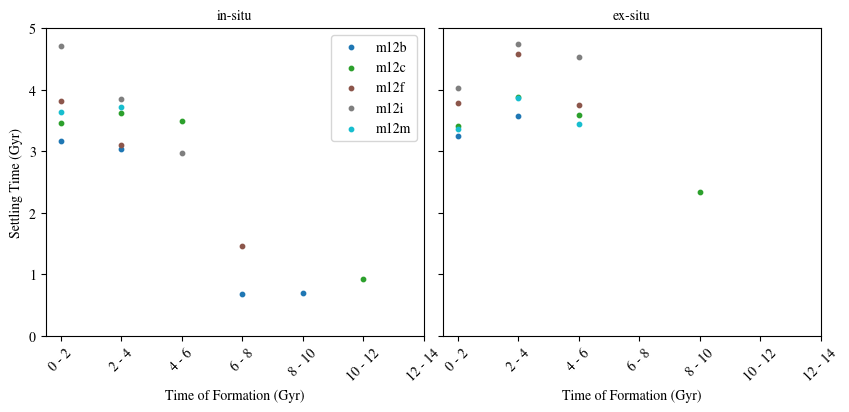

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(30 / 3, 4), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05)

for k, sim in enumerate(sim_lst):
    for j, acc in enumerate(accs):
        x = []
        y = []
        y_err = []
        for i in range(1, len(tfor_bins)):
            men = np.mean(set_age_dict[sim][i][acc])
            std = np.std(set_age_dict[sim][i][acc])

            x.append(i)
            y.append(men)
            y_err.append(std)

            # c=sim_colors[j], ls="--", lw=2, label=sim
        # axs[j].plot(x, y, c=sim_colors[k], label=sim, marker=".")
        axs[j].scatter(x, y, c=sim_colors[k], label=sim, s=10)

axs[0].set_title("in-situ")
axs[1].set_title("ex-situ")

axs[0].set_xlabel("Time of Formation (Gyr)")
axs[1].set_xlabel("Time of Formation (Gyr)")

axs[0].set_ylabel("Settling Time (Gyr)")

axs[0].set_ylim(0, 5)
axs[1].set_ylim(0, 5)

axs[0].legend()

for j in [0, 1]:
    x_ticks = []
    x_positions = []

    for i in range(1, len(tfor_bins)):
        x_ticks.append(f"{tfor_bins[i - 1]} - {tfor_bins[i]}")
        x_positions.append(i)  # <-- match x.append(i)

    axs[j].set_xticks(x_positions)
    axs[j].set_xticklabels(x_ticks, rotation=45)